In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import tifffile
from skimage.measure import regionprops_table

# ----------------------- CONFIG -----------------------
folders_to_read = [
    Path(r"Z:\Jorge\SPACEFISH_analysis\2026\v115-3Drep2-0101-indinuc"),
    Path(r"Z:\Jorge\SPACEFISH_analysis\2026\v115-vascu-0101-indinuc"),
]
subfolders_to_skip = [
    Path(r"Z:\Jorge\SPACEFISH_analysis\2026\v115-3Drep2-0101-indinuc\results\dev1_2_6h"),
]
output_dir = Path(r"c:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish")
# ------------------------------------------------------

output_dir.mkdir(parents=True, exist_ok=True)
skip_resolved = {p.resolve() for p in subfolders_to_skip}


def is_skipped(folder: Path) -> bool:
    rp = folder.resolve()
    return rp in skip_resolved or any(parent in skip_resolved for parent in rp.parents)


def find_image_folders(roots):
    """An 'image folder' is any folder containing a *count_table*.csv."""
    found = []
    for root in roots:
        for csv in root.rglob("*count_table*.csv"):
            folder = csv.parent
            if is_skipped(folder):
                print(f"[SKIP - excluded] {folder}")
                continue
            found.append(folder)
    return sorted(set(found))


def centroids_from_mask(mask: np.ndarray):
    """Return (props_df, (Xmax, Ymax, Zmax)). Mask assumed (Z, Y, X) if 3D."""
    mask = np.squeeze(mask)
    props = pd.DataFrame(regionprops_table(mask, properties=("label", "centroid")))
    if mask.ndim == 3:
        props = props.rename(columns={
            "centroid-0": "nucleus_centroid_z",
            "centroid-1": "nucleus_centroid_y",
            "centroid-2": "nucleus_centroid_x",
        })
        zmax, ymax, xmax = mask.shape
    else:  # 2D fallback
        props = props.rename(columns={
            "centroid-0": "nucleus_centroid_y",
            "centroid-1": "nucleus_centroid_x",
        })
        props["nucleus_centroid_z"] = np.nan
        ymax, xmax = mask.shape
        zmax = 1
    return props, (int(xmax), int(ymax), int(zmax))



In [3]:
import random

# ---- SANITY CHECK: does nucleus_xyz.csv match centroids derived from seg_mask? ----
_check_cache = {}  # folder.name -> merged dataframe (so we don't reload masks)

def check_one(folder: Path):
    seg_path = next(iter(folder.glob("*seg_mask*.tif")), None)
    xyz_path = folder / "nucleus_xyz.csv"
    if seg_path is None or not xyz_path.exists():
        return None

    mask = np.squeeze(tifffile.imread(str(seg_path)))
    props, (xmax, ymax, zmax) = centroids_from_mask(mask)
    props = props.rename(columns={"label": "nucleus"})

    xyz = pd.read_csv(xyz_path).rename(columns={"ID": "nucleus"})
    m = props.merge(xyz, on="nucleus", how="inner")
    _check_cache[folder.name] = m.copy()

    # direct mapping (centroid_x vs xyz.x, etc.)
    dx = (m["nucleus_centroid_x"] - m["x"]).abs()
    dy = (m["nucleus_centroid_y"] - m["y"]).abs()
    dz = (m["nucleus_centroid_z"] - m["z"]).abs()
    # swapped mapping (centroid_x vs xyz.y, centroid_y vs xyz.x)
    dx_s = (m["nucleus_centroid_x"] - m["y"]).abs()
    dy_s = (m["nucleus_centroid_y"] - m["x"]).abs()
    return {
        "folder": folder.name,
        "mask_shape_ZYX": mask.shape,
        "n_matched": len(m),
        "max_dx": dx.max(), "max_dy": dy.max(), "max_dz": dz.max(),
        "mean_dx": dx.mean(), "mean_dy": dy.mean(), "mean_dz": dz.mean(),
        "max_dx_swap": dx_s.max(), "max_dy_swap": dy_s.max(),
        "mean_dx_swap": dx_s.mean(), "mean_dy_swap": dy_s.mean(),
    }

_folders = find_image_folders(folders_to_read)
_sample = random.sample(_folders, min(4, len(_folders)))
report = pd.DataFrame([r for f in _sample if (r := check_one(f))])
report


[SKIP - excluded] Z:\Jorge\SPACEFISH_analysis\2026\v115-3Drep2-0101-indinuc\results\dev1_2_6h


,folder,mask_shape_ZYX,n_matched,max_dx,max_dy,max_dz,mean_dx,mean_dy,mean_dz,max_dx_swap,max_dy_swap,mean_dx_swap,mean_dy_swap
0,dev9_4_day4,"(126, 3930, 3933)",645,3492.937532,3494.945576,2.867423,1267.824355,1268.540583,1.053064,6.464122,8.371596,1.111194,1.253711
1,dev7_3_day1_large,"(252, 5799, 5811)",2530,5650.532523,5646.022329,4.376836,1968.872291,1968.847870,1.056238,13.102953,8.541668,1.104334,1.194437
2,dev8_3_day4,"(126, 3906, 3930)",815,3810.249745,3813.077528,4.025384,1331.143630,1331.309071,1.072021,5.857744,11.352594,1.151760,1.177036
3,dev8_2_day1_noamp,"(126, 2067, 3873)",266,3506.476248,3508.951240,3.864559,1201.478779,1202.727941,1.073848,6.346118,6.608980,1.122268,1.140993


In [4]:
def source_root_name(folder: Path) -> str:
    """Name of the top-level root in folders_to_read that contains this folder."""
    rp = folder.resolve()
    for root in folders_to_read:
        rr = root.resolve()
        if rp == rr or rr in rp.parents:
            return root.name
    return "UNKNOWN"


def mask_extent(seg_path: Path):
    """Read only the array shape (no pixel data) -> (Xmax, Ymax, Zmax)."""
    shape = tifffile.TiffFile(str(seg_path)).series[0].shape
    shape = tuple(s for s in shape if s > 1)  # drop singleton axes
    if len(shape) == 3:
        zmax, ymax, xmax = shape
    else:
        ymax, xmax = shape
        zmax = 1
    return int(xmax), int(ymax), int(zmax)


all_tables = []
image_folders = find_image_folders(folders_to_read)
print(f"Found {len(image_folders)} candidate image folders.\n")

for folder in image_folders:
    count_csv = next(iter(folder.glob("*count_table*.csv")), None)
    seg_path = next(iter(folder.glob("*seg_mask*.tif")), None)
    xyz_path = folder / "nucleus_xyz.csv"

    if seg_path is None:
        print(f"[SKIP - no seg_mask] {folder}")
        continue
    if not xyz_path.exists():
        print(f"[SKIP - no nucleus_xyz.csv] {folder}")
        continue

    df = pd.read_csv(count_csv)

    # Centroids from nucleus_xyz.csv (fast). NOTE: validated x<->y swap vs seg_mask.
    xyz = pd.read_csv(xyz_path).rename(columns={
        "ID": "nucleus",
        "x": "nucleus_centroid_y",   # csv 'x' is image row (Y)
        "y": "nucleus_centroid_x",   # csv 'y' is image column (X)
        "z": "nucleus_centroid_z",
    })[["nucleus", "nucleus_centroid_x", "nucleus_centroid_y", "nucleus_centroid_z"]]
    df = df.merge(xyz, on="nucleus", how="left")

    # Extent from mask header only (no full load).
    xmax, ymax, zmax = mask_extent(seg_path)
    df["Xmax"], df["Ymax"], df["Zmax"] = xmax, ymax, zmax

    # Provenance: which root folder this image came from.
    df.insert(0, "source_folder", source_root_name(folder))

    out_name = f"{folder.name}_count_table_xyz.csv"
    df.to_csv(output_dir / out_name, index=False)
    all_tables.append(df)
    n_missing = df["nucleus_centroid_x"].isna().sum()
    print(f"[OK] {folder.name} [{df['source_folder'].iloc[0]}]: "
          f"{len(df)} nuclei ({n_missing} missing centroid), extent (X,Y,Z)=({xmax},{ymax},{zmax})")

# Concatenate every nucleus from every image into one table.
if all_tables:
    combined = pd.concat(all_tables, ignore_index=True)
    combined.to_csv(output_dir / "all_nuclei.csv", index=False)
    print(f"\nCombined table: {combined.shape[0]} nuclei x {combined.shape[1]} columns")
    print(f"Saved -> {output_dir / 'all_nuclei.csv'}")
else:
    print("\nNo folders produced output.")


[SKIP - excluded] Z:\Jorge\SPACEFISH_analysis\2026\v115-3Drep2-0101-indinuc\results\dev1_2_6h
Found 24 candidate image folders.

[OK] dev1_3_6h [v115-3Drep2-0101-indinuc]: 1000 nuclei (0 missing centroid), extent (X,Y,Z)=(3933,3945,126)
[SKIP - no nucleus_xyz.csv] Z:\Jorge\SPACEFISH_analysis\2026\v115-3Drep2-0101-indinuc\results\dev1_4_6h
[OK] dev3_2_day1 [v115-3Drep2-0101-indinuc]: 944 nuclei (0 missing centroid), extent (X,Y,Z)=(4059,4074,126)
[OK] dev3_3_day1 [v115-3Drep2-0101-indinuc]: 1032 nuclei (0 missing centroid), extent (X,Y,Z)=(3945,3942,126)
[OK] dev6_2_day2 [v115-3Drep2-0101-indinuc]: 862 nuclei (0 missing centroid), extent (X,Y,Z)=(3930,3978,126)
[OK] dev6_3_day2 [v115-3Drep2-0101-indinuc]: 856 nuclei (0 missing centroid), extent (X,Y,Z)=(3948,3954,126)
[OK] dev6_4_day2 [v115-3Drep2-0101-indinuc]: 758 nuclei (0 missing centroid), extent (X,Y,Z)=(3936,3951,126)
[OK] dev8_2_day4 [v115-3Drep2-0101-indinuc]: 710 nuclei (0 missing centroid), extent (X,Y,Z)=(3936,3909,126)
[OK]

In [7]:
combined.head()

,source_folder,name,nucleus,CDH5,MMP1,COL1A1,KDR,VWF,PECAM1,VEGFA,...,FP4col12,FP4col13,FP4col14,FP4col15,nucleus_centroid_x,nucleus_centroid_y,nucleus_centroid_z,Xmax,Ymax,Zmax
0,v115-3Drep2-0101-indinuc,dev1_3_6h,1,0,0,0,0,0,0,1,...,0,0,0,0,3420.720565,1315.118849,24,3933,3945,126
1,v115-3Drep2-0101-indinuc,dev1_3_6h,2,1,0,0,0,1,1,0,...,0,0,0,0,3344.176875,1313.184155,23,3933,3945,126
2,v115-3Drep2-0101-indinuc,dev1_3_6h,3,0,0,0,0,2,0,0,...,0,0,0,0,3294.685265,1413.751726,23,3933,3945,126
3,v115-3Drep2-0101-indinuc,dev1_3_6h,4,0,0,0,0,0,0,0,...,0,0,0,0,3831.060972,1448.324364,24,3933,3945,126
4,v115-3Drep2-0101-indinuc,dev1_3_6h,5,2,0,0,0,0,0,0,...,0,0,0,0,1924.543792,1829.677652,28,3933,3945,126


In [ ]:
# Gene-state analysis

Binarise the true-gene channels (FP false-positive channels excluded), build readable
state labels, keep biologically informative recurrent states, then explore and cluster them.


,source_folder,name,nucleus,CDH5,MMP1,COL1A1,KDR,VWF,PECAM1,VEGFA,...,FP4col13,FP4col14,FP4col15,nucleus_centroid_x,nucleus_centroid_y,nucleus_centroid_z,Xmax,Ymax,Zmax,gene_ID
0,v115-3Drep2-0101-indinuc,dev1_3_6h,1,0,0,0,0,0,0,1,...,0,0,0,3420.720565,1315.118849,24,3933,3945,126,000000100000000000
1,v115-3Drep2-0101-indinuc,dev1_3_6h,2,1,0,0,0,1,1,0,...,0,0,0,3344.176875,1313.184155,23,3933,3945,126,100011000000100000
2,v115-3Drep2-0101-indinuc,dev1_3_6h,3,0,0,0,0,1,0,0,...,0,0,0,3294.685265,1413.751726,23,3933,3945,126,000020000002100000
3,v115-3Drep2-0101-indinuc,dev1_3_6h,4,0,0,0,0,0,0,0,...,0,0,0,3831.060972,1448.324364,24,3933,3945,126,000000000000000000
4,v115-3Drep2-0101-indinuc,dev1_3_6h,5,1,0,0,0,0,0,0,...,0,0,0,1924.543792,1829.677652,28,3933,3945,126,200000000000000000


In [31]:
# Identify gene columns. Everything that is not metadata is a gene measurement;
# FP* columns are false-positive QC channels and are excluded from the biology.
metadata_cols = {
    "name", "source_folder", "nucleus",
    "nucleus_centroid_x", "nucleus_centroid_y", "nucleus_centroid_z",
    "Xmax", "Ymax", "Zmax",
    "gene_ID", "binary_state", "state_code",  # derived label columns, not genes
}
gene_columns = [c for c in combined.columns if c not in metadata_cols]
fp_columns = [c for c in gene_columns if c.startswith("FP")]
true_gene_columns = [c for c in gene_columns if not c.startswith("FP")]

print(f"{len(true_gene_columns)} true gene columns: {true_gene_columns}")
print(f"{len(fp_columns)} FP columns (excluded): {fp_columns}")


18 true gene columns: ['CDH5', 'MMP1', 'COL1A1', 'KDR', 'VWF', 'PECAM1', 'VEGFA', 'DLL4', 'ITGA6', 'SEMA3F', 'JAG1', 'FLT1', 'PDGFB', 'COL1A2', 'APLN', 'PDGFRB', 'ANGPT2', 'ICAM1']
38 FP columns (excluded): ['FP2col1', 'FP2col2', 'FP2col3', 'FP3col1', 'FP3col2', 'FP3col3', 'FP3col4', 'FP3col5', 'FP3col6', 'FP3col7', 'FP3col8', 'FP3col9', 'FP3col10', 'FP3col11', 'FP3col12', 'FP3col13', 'FP3col14', 'FP3col15', 'FP3col16', 'FP3col17', 'FP3col18', 'FP3col19', 'FP3col20', 'FP4col1', 'FP4col2', 'FP4col3', 'FP4col4', 'FP4col5', 'FP4col6', 'FP4col7', 'FP4col8', 'FP4col9', 'FP4col10', 'FP4col11', 'FP4col12', 'FP4col13', 'FP4col14', 'FP4col15']


In [32]:
# Binarise the true-gene channels and build readable per-cell state labels.
df = combined.copy()

# Any detected transcript (>= 1 count, incl. 2+) -> 1, otherwise 0.
df[true_gene_columns] = (df[true_gene_columns].fillna(0).astype(float) > 0).astype(int)

# binary_state: one digit per gene in column order, e.g. "100100000001000000"
df["binary_state"] = df[true_gene_columns].astype(str).agg("".join, axis=1)

# state_code: 1-based indices of the ON genes, e.g. "1_4_12"
df["state_code"] = df[true_gene_columns].apply(
    lambda row: "_".join(str(i + 1) for i, value in enumerate(row) if value == 1),
    axis=1,
).replace("", "0")  # all-negative cells get the code "0"

df[["binary_state", "state_code"]].head()


,binary_state,state_code
0,000000100000000000,7
1,100011000000100000,1_5_6_13
2,000010000001100000,5_12_13
3,000000000000000000,0
4,100000000000000000,1


In [33]:
# Keep biologically informative cells and recurrent states.
min_cells_per_state = 3                       # states must occur in > 2 cells
all_negative = "0" * len(true_gene_columns)

# Drop all-negative cells (no transcripts detected -> not interesting).
df_expressed = df[df["binary_state"] != all_negative].copy()

# Count cells per state and keep the recurrent ones.
state_counts = df_expressed["state_code"].value_counts()
recurrent_states = state_counts[state_counts >= min_cells_per_state].index
df_recurrent = df_expressed[df_expressed["state_code"].isin(recurrent_states)].copy()

n_total = len(df)
print(f"All cells:                         {n_total:,}")
print(f"Cells with >=1 transcript:         {len(df_expressed):,} ({100*len(df_expressed)/n_total:.1f}%)")
print(f"Unique expressed states:           {state_counts.size:,}")
print(f"Recurrent states (> 2 cells):      {len(recurrent_states):,}")
print(f"Cells in recurrent states:         {len(df_recurrent):,} ({100*len(df_recurrent)/n_total:.1f}%)")


All cells:                         21,014
Cells with >=1 transcript:         13,498 (64.2%)
Unique expressed states:           1,761
Recurrent states (> 2 cells):      467
Cells in recurrent states:         11,979 (57.0%)


In [34]:
# Summary table of recurrent states, ranked by frequency.
state_summary = (
    df_recurrent.groupby(["state_code", "binary_state"])
    .size().reset_index(name="n_cells")
    .sort_values("n_cells", ascending=False)
    .reset_index(drop=True)
)
state_summary["pct_all_cells"] = 100 * state_summary["n_cells"] / n_total
state_summary["pct_expressed_cells"] = 100 * state_summary["n_cells"] / len(df_expressed)
state_summary.head(20)


,state_code,binary_state,n_cells,pct_all_cells,pct_expressed_cells
0,1,100000000000000000,1545,7.352241,11.446140
1,7,000000100000000000,734,3.492909,5.437843
2,4,000100000000000000,685,3.259732,5.074826
3,1_4,100100000000000000,505,2.403160,3.741295
4,5,000010000000000000,408,1.941563,3.022670
5,1_7,100000100000000000,341,1.622728,2.526300
6,1_5,100010000000000000,327,1.556105,2.422581
7,1_4_7,100100100000000000,269,1.280099,1.992888
8,1_8,100000010000000000,221,1.051680,1.637280
9,8,000000010000000000,197,0.937470,1.459475


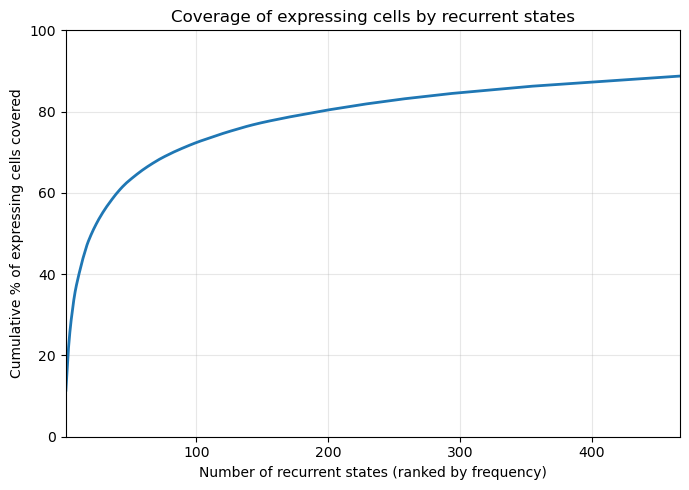

In [35]:
# Coverage: how many recurrent states are needed to account for the expressing cells.
import matplotlib.pyplot as plt

coverage = state_summary.copy()
coverage["rank"] = np.arange(1, len(coverage) + 1)
coverage["cum_pct_expressed"] = 100 * coverage["n_cells"].cumsum() / len(df_expressed)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(coverage["rank"], coverage["cum_pct_expressed"], linewidth=2)
ax.set_xlabel("Number of recurrent states (ranked by frequency)")
ax.set_ylabel("Cumulative % of expressing cells covered")
ax.set_title("Coverage of expressing cells by recurrent states")
ax.set_xlim(1, len(coverage))
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


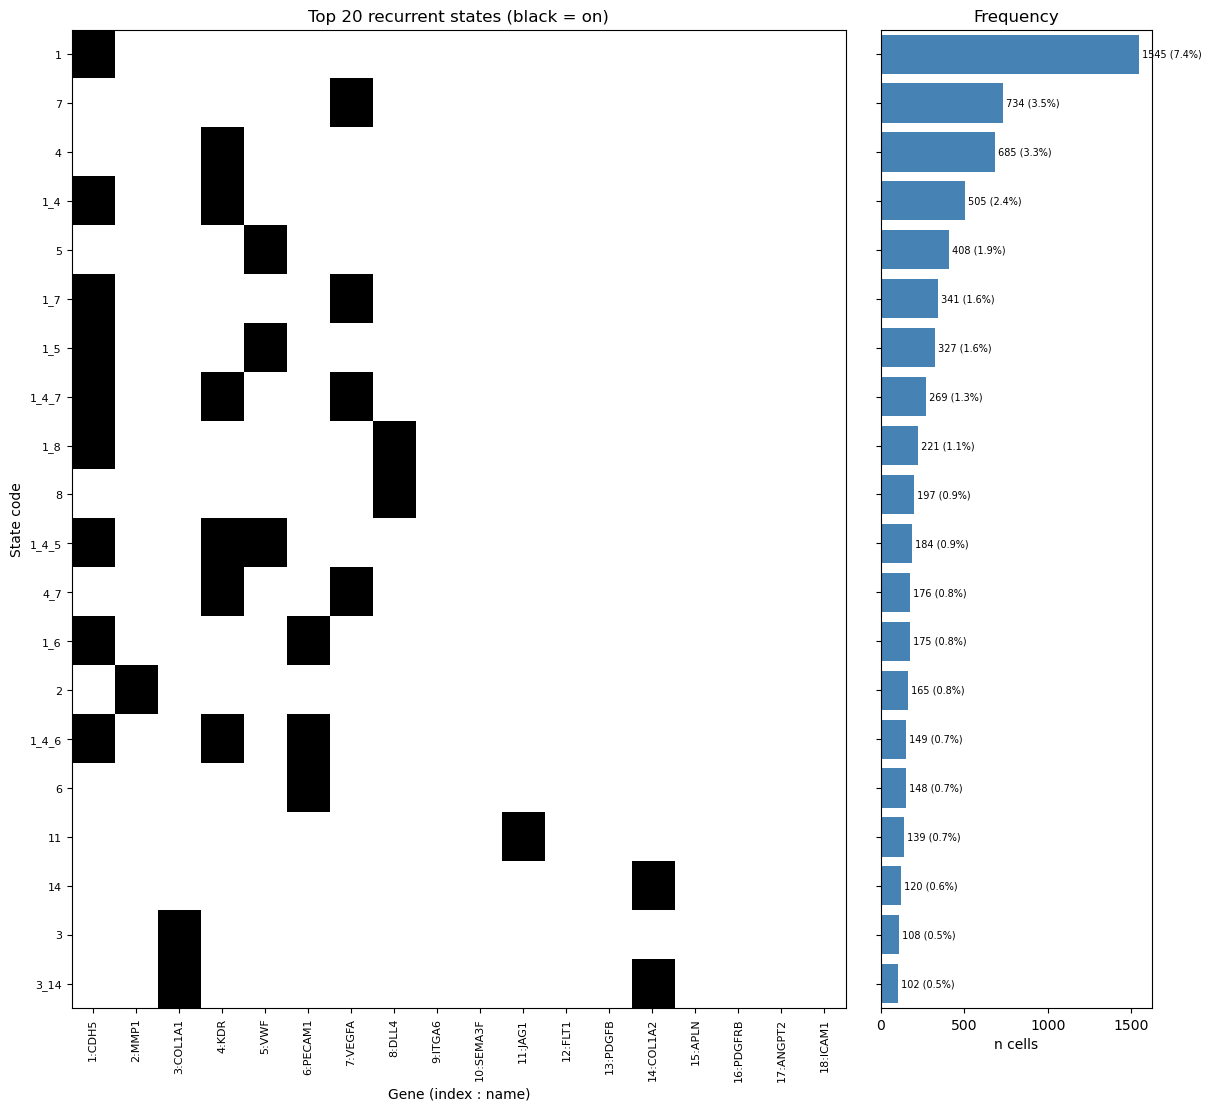

In [38]:
# Recurrent-state heatmap: rows = states, columns = genes 1-18, values = on/off.
# A side annotation shows n_cells and % of all cells, making families (e.g. 1_4,
# 1_4_7, 1_4_11, 1_4_12) easy to spot.
top_n = 20
top_states = state_summary.head(top_n).copy()

state_onoff = pd.DataFrame(
    [[int(ch) for ch in bs] for bs in top_states["binary_state"]],
    columns=[f"{i + 1}:{g}" for i, g in enumerate(true_gene_columns)],
    index=top_states["state_code"],
)

fig, (ax_hm, ax_bar) = plt.subplots(
    1, 2, figsize=(12, 0.45 * top_n + 2),
    gridspec_kw={"width_ratios": [4, 1.4], "wspace": 0.05}, sharey=True,
    constrained_layout=True,
)

ax_hm.imshow(state_onoff.values, aspect="auto", cmap="Greys", vmin=0, vmax=1)
ax_hm.set_xticks(range(len(state_onoff.columns)))
ax_hm.set_xticklabels(state_onoff.columns, rotation=90, fontsize=8)
ax_hm.set_yticks(range(len(state_onoff.index)))
ax_hm.set_yticklabels(state_onoff.index, fontsize=8)
ax_hm.set_xlabel("Gene (index : name)")
ax_hm.set_ylabel("State code")
ax_hm.set_title(f"Top {top_n} recurrent states (black = on)")

y = np.arange(len(top_states))
ax_bar.barh(y, top_states["n_cells"], color="steelblue")
ax_bar.set_xlabel("n cells")
ax_bar.set_title("Frequency")
for yi, (n, pct) in enumerate(zip(top_states["n_cells"], top_states["pct_all_cells"])):
    ax_bar.text(n, yi, f" {n} ({pct:.1f}%)", va="center", fontsize=7)
ax_bar.set_ylim(ax_hm.get_ylim())  # align bars with heatmap rows
plt.show()



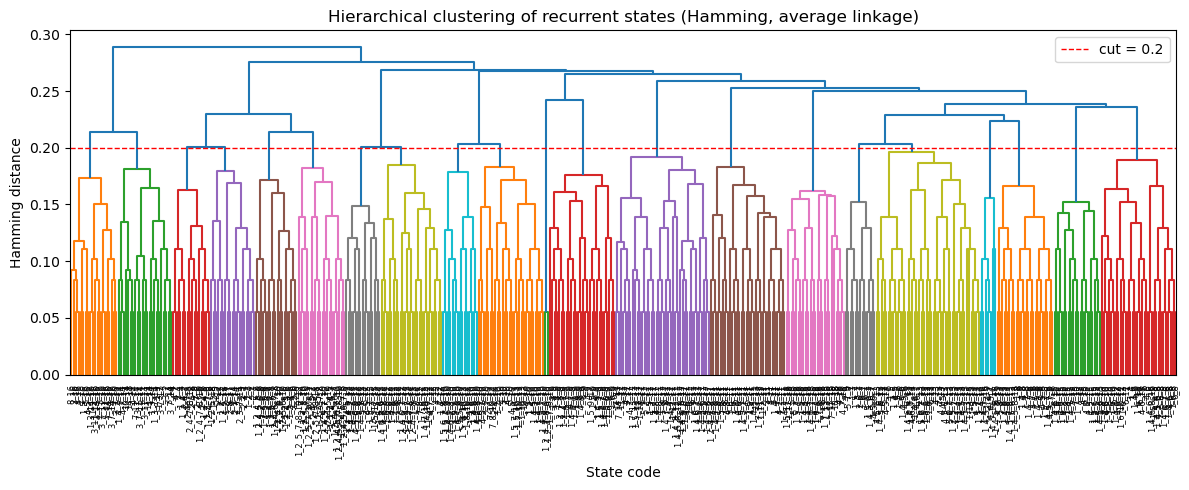

467 recurrent states -> 21 clusters


,cluster_id,n_states,n_cells,example_states,pct_all_cells
0,21,32,2825,"1, 1_4, 1_6, 1_4_6, 6",13.443419
1,17,44,1737,"5, 1_5, 1_4_5, 4_5, 13",8.265918
2,16,13,1342,"7, 1_7, 1_5_7, 5_7, 1_6_7",6.386219
3,3,16,1085,"4, 4_7, 1_2_4_7, 2_4, 1_2_4",5.163225
4,19,24,896,"1_8, 8, 1_4_8, 1_5_8, 1_7_8",4.263824
5,2,23,657,"14, 3, 3_14, 3_7, 3_7_14",3.126487
6,4,19,431,"2, 1_2, 1_2_7, 2_7, 1_2_5",2.051014
7,14,32,409,"11, 1_11, 7_11, 4_11, 1_7_11",1.946321
8,13,40,389,"17, 1_17, 1_4_17, 4_17, 7_17",1.851147
9,10,28,369,"1_10, 10, 7_10, 1_7_10, 1_5_10",1.755972


Saved -> recurrent_states_summary.csv, recurrent_state_clusters.csv


In [37]:
# Cluster the recurrent states using Hamming distance on the 18-gene binary
# vectors with average-linkage hierarchical clustering.
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

hamming_threshold = 0.20  # states within this fractional bit-difference are grouped

state_vectors = np.array(
    [[int(ch) for ch in bs] for bs in state_summary["binary_state"]], dtype=np.uint8
)

dist_condensed = pdist(state_vectors, metric="hamming")
Z = linkage(dist_condensed, method="average")
state_summary["cluster_id"] = fcluster(Z, t=hamming_threshold, criterion="distance")

dist_matrix = squareform(dist_condensed)
np.fill_diagonal(dist_matrix, np.inf)
state_summary["nearest_neighbor_hamming"] = dist_matrix.min(axis=1)

# Per-cluster summary.
cluster_summary = (
    state_summary.groupby("cluster_id")
    .agg(
        n_states=("state_code", "size"),
        n_cells=("n_cells", "sum"),
        example_states=("state_code", lambda s: ", ".join(s.head(5))),
    )
    .reset_index()
    .sort_values("n_cells", ascending=False)
    .reset_index(drop=True)
)
cluster_summary["pct_all_cells"] = 100 * cluster_summary["n_cells"] / n_total

# Dendrogram of recurrent states.
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, labels=state_summary["state_code"].values, color_threshold=hamming_threshold, ax=ax)
ax.axhline(hamming_threshold, color="red", ls="--", lw=1, label=f"cut = {hamming_threshold}")
ax.set_xlabel("State code")
ax.set_ylabel("Hamming distance")
ax.set_title("Hierarchical clustering of recurrent states (Hamming, average linkage)")
ax.legend()
plt.xticks(fontsize=6)
plt.tight_layout()
plt.show()

print(f"{len(state_summary)} recurrent states -> {state_summary['cluster_id'].nunique()} clusters")
display(cluster_summary.head(20))

# Save outputs.
state_summary.to_csv(output_dir / "recurrent_states_summary.csv", index=False)
cluster_summary.to_csv(output_dir / "recurrent_state_clusters.csv", index=False)
print("Saved -> recurrent_states_summary.csv, recurrent_state_clusters.csv")
